# Exercício 1: Teorema Central do Limite

Considere o **Teorema Central do Limite (TCL)**. Sejam $X_1, \ldots, X_n$ variáveis aleatórias i.i.d., com média $\mu$ e variância finita $\sigma^2$. Então,

$$
\frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}
\xrightarrow{d}
N(0,1),
$$

quando $n \to \infty$.

O objetivo deste exercício é verificar empiricamente o comportamento descrito pelo TCL para diferentes distribuições e diferentes valores de $n$.

1. Considere as seguintes distribuições para $X$:

   * Uniforme;
   * Bernoulli;
   * Geométrica;
   * Poisson.

   Para cada distribuição, escolha diferentes valores de $n$ e gere $M = 5000$ realizações da variável aleatória

   $$
   Z_n = \frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}.
   $$

   Compare o comportamento da distribuição de $Z_n$ conforme o valor de $n$ aumenta.

2. Para cada distribuição e para cada valor de $n$, construa um histograma das $M = 5000$ realizações de $Z_n$.

   Compare os histogramas obtidos com uma amostra de uma distribuição normal padrão $N(0,1)$ gerada diretamente pelo NumPy.

3. Analise os resultados obtidos e discuta:

   * como a aproximação pela distribuição normal muda conforme $n$ aumenta;
   * quais distribuições apresentam convergência mais rápida para a normal;
   * como o formato da distribuição original influencia a qualidade da aproximação para valores pequenos de $n$.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

In [ ]:
#Uniforme
amostra = []
media = 0.5
var = 1/12

N = 5000
for i in range(N):
  n = 100
  amostrinha = []
  for i in range(n):
    uniforme = np.random.uniform()
    amostrinha.append(uniforme)
  x_barra = np.mean(amostrinha)
  z = (np.sqrt(n)*(x_barra - media))/np.sqrt(var)
  amostra.append(z)




Text(0.5, 1.0, 'Uniforme')

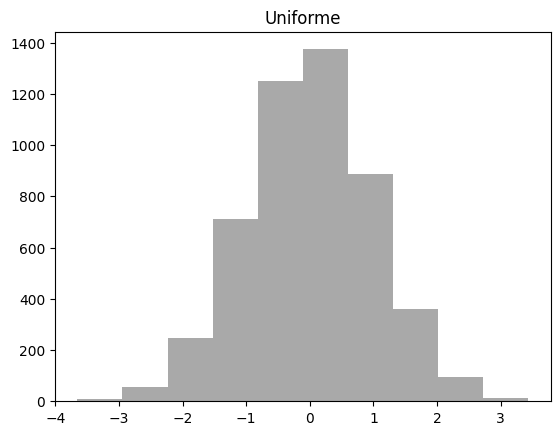

In [ ]:
plt.hist(amostra, color = "darkgray")
plt.title("Uniforme")

In [ ]:
n = 500
p = 0.5
M = 5000
amostra_ber = []
var_ber = p*(1-p)

for i in range(M):
  x_bar  = np.mean(np.random.uniform(size = n) < p)
  z_ber = (n**0.5)*(x_bar - p)/(var_ber**0.5)
  amostra_ber.append(z_ber)

Text(0.5, 1.0, 'Bernoulli')

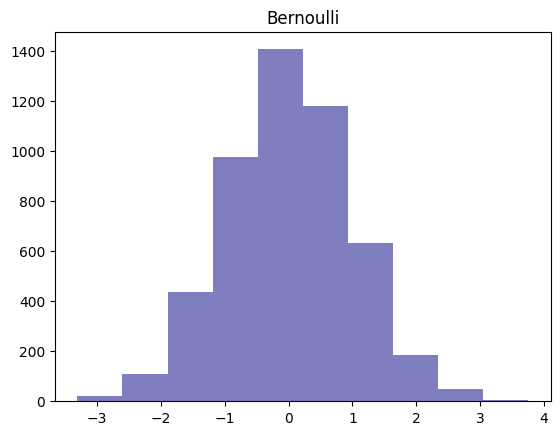

In [ ]:
plt.hist(amostra_ber, color = "navy", alpha = .5)
plt.title("Bernoulli")

In [ ]:
amostra_geo = []
N = 5000
p = .5
var_geo = (1-p)/(p**2)
for i in range (N):
  n = 50
  amostra_esperta = []
  for i in range(n):
    u = np.random.uniform()
    num = np.log(1-u)
    dem = np.log(1-p)
    x = np.floor(num/dem) + 1
    amostra_esperta.append(x)
  amostra_geo.append((n**0.5*(np.mean(amostra_esperta) - (1/p)))/(var_geo**0.5))


Text(0.5, 1.0, 'Geometrica')

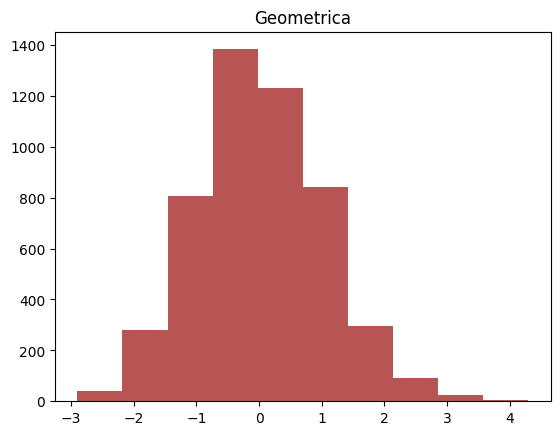

In [ ]:
plt.hist(amostra_geo, color = "brown", alpha = 0.8)
plt.title("Geometrica")

In [ ]:
amostra_poisson = []
N = 5000
for i in range (N):
  amostra_esp = []
  n = 100
  for i in range(n):
    u = np.random.uniform()
    lam = 8
    i = 0
    p = np.exp(-lam)
    F = p

    while u>F:
      i = i+1
      p = p*(lam/i)
      F = F + p

    x = i
    amostra_esp.append(x)
  amostra_poisson.append((n**0.5*(np.mean(amostra_esp) - (lam)))/(lam**0.5))

(array([   5.,   23.,  180.,  597., 1225., 1506.,  972.,  400.,   80.,
          12.]),
 array([-3.99515331, -3.23854906, -2.4819448 , -1.72534055, -0.96873629,
        -0.21213203,  0.54447222,  1.30107648,  2.05768073,  2.81428499,
         3.57088924]),
 <BarContainer object of 10 artists>)

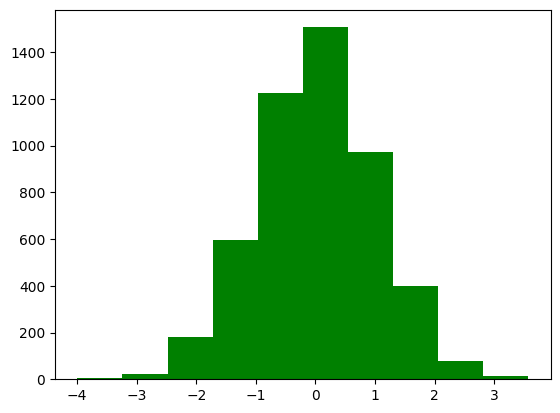

In [ ]:
plt.hist(amostra_poisson, color = "green")

(array([   2.,   25.,  118.,  504., 1187., 1478., 1083.,  473.,  110.,
          20.]),
 array([-4.23158597, -3.45370627, -2.67582657, -1.89794687, -1.12006717,
        -0.34218747,  0.43569223,  1.21357193,  1.99145163,  2.76933133,
         3.54721103]),
 <BarContainer object of 10 artists>)

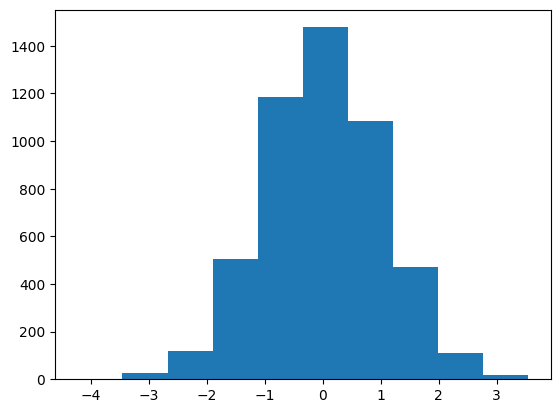

In [ ]:
normal = np.random.normal(0,1,5000)
plt.hist(normal)

*  Percebemos que quanto maior o valor de n, melhor torna-se a convergência da distribuição para a normal(0,1), o que é um efeito direto do teorema do limite central.
* A distribuição que convergiu mais rapidamente foi a uniforme, creio que por já possuir uma simetria assim como a normal e possuir um suporte limitado.
* Acredito que interferência do formato da distribuição original seja o citado anteriormente em que irá depender da simetria e do suporte da distribuição original.





# Exercício 2: Aproximação de Poisson

Como vimos em sala, se $X_n \sim \operatorname{Binomial}(n,p_n),$ com $p_n = \frac{\lambda}{n},$ então, para $\lambda > 0$ fixo,

$$
X_n \xrightarrow{d} \operatorname{Poisson}(\lambda)
$$

quando $n \to \infty$.

Em outras palavras, quando $n$ aumenta e $p_n$ diminui de forma que $np_n = \lambda,$ a distribuição $\operatorname{Binomial}(n,p_n)$ se aproxima de uma distribuição $\operatorname{Poisson}(\lambda)$.

1. Fixe um valor de $\lambda$ e um tamanho de amostra $M$. Para diferentes valores de $n$:

   * defina $p_n = \lambda/n$;
   * gere uma amostra de tamanho $M$ de variáveis

   $$
   X_n \sim \operatorname{Binomial}\left(n,\frac{\lambda}{n}\right);
   $$

   * compare as distribuições obtidas para diferentes valores de $n$ e analise o efeito do aumento de $n$ na aproximação pela distribuição de Poisson.

2. Para verificar a qualidade da aproximação, compare as amostras obtidas pelo método binomial com:

   * uma amostra de tamanho $M$ gerada diretamente por `numpy.random.poisson`;
   * uma amostra de tamanho $M$ de variáveis $\operatorname{Poisson}(\lambda)$ geradas utilizando o **método recursivo**.

3. Para cada método, construa histogramas ou gráficos de frequências e compare as distribuições empíricas obtidas.

4. Compare também o **tempo de execução** dos dois métodos:

   * aproximação por $\operatorname{Binomial}(n,\lambda/n)$;
   * geração de Poisson pelo método da inversão.

5. Discuta os resultados obtidos, considerando:

   * como o valor de $n$ influencia a qualidade da aproximação binomial-Poisson;
   * se as distribuições empíricas produzidas pelos três métodos são semelhantes;
   * as diferenças de tempo de execução entre os métodos;
   * as vantagens e desvantagens de cada método de geração.


In [ ]:
#Exercício 2
M = 10000
lamb = 8
n = 5000
p = lamb/n
amostra = []

for j in range(M):
  i = 0
  pi = (1-p)**n
  F = pi
  U = np.random.uniform(0,1, size = 1)
  while U>F:
    pi = (((n-i)/(i+1))*(p/(1-p)))*pi
    i = i+1
    F = F+pi
  amostra.append(i)

In [ ]:
poisson = np.random.poisson(8, 10000)

In [ ]:
#Exercício 3
amostra_poisson_recursiva = []
N = 10000
for i in range(N):
  u = np.random.uniform()
  lam = 8
  i = 0
  p = np.exp(-lam)
  F = p

  while u>F:
    i = i+1
    p = p*(lam/i)
    F = F + p

  x = i
  amostra_poisson_recursiva.append(x)

(array([ 153.,  839., 2125., 2820., 2198., 1206.,  480.,  141.,   32.,
           6.]),
 array([ 0. ,  2.1,  4.2,  6.3,  8.4, 10.5, 12.6, 14.7, 16.8, 18.9, 21. ]),
 <BarContainer object of 10 artists>)

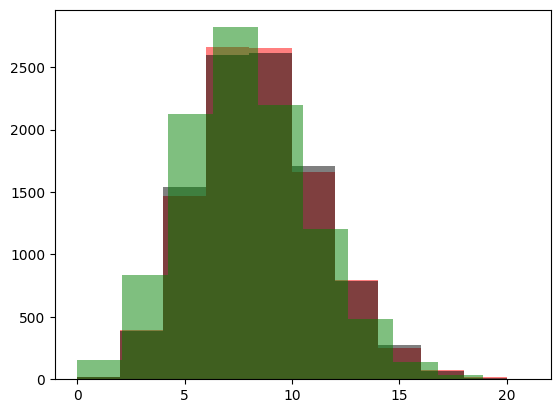

In [ ]:
plt.hist(amostra, color= 'Red' ,alpha= 0.5)
plt.hist(poisson, color = "black", alpha = 0.5)
plt.hist(amostra_poisson_recursiva, color = 'green', alpha = 0.5)



In [ ]:
M = 10000
lamb = 8
n = 5000
p = lamb/n
amostra = []
inicio = time.time()
for j in range(M):
  i = 0
  pi = (1-p)**n
  F = pi
  U = np.random.uniform(0,1, size = 1)
  while U>F:
    pi = (((n-i)/(i+1))*(p/(1-p)))*pi
    i = i+1
    F = F+pi
  amostra.append(i)
fim = time.time()
tempo = fim - inicio
#Método Inversão
amostra_poisson_recursiva = []
N = 10000
inicio_rec = time.time()
for i in range(N):
  u = np.random.uniform()
  lam = 8
  i = 0
  p = np.exp(-lam)
  F = p

  while u>F:
    i = i+1
    p = p*(lam/i)
    F = F + p

  x = i
  amostra_poisson_recursiva.append(x)
  fim_rec = time.time()
  tempo_rec = fim_rec - inicio_rec

In [ ]:
print("Os tempos de execução foram de: ")
print(f"{tempo:.4f} para o método da aproximação e {tempo_rec:.4f} para o método da inversão")

Os tempos de execução foram de: 
0.2386 para o método da aproximação e 0.0892 para o método da inversão


Discursões

*  Novamente quando maior o valor de n, melhor será a aproximação, visto que estamos fazendo uma distribuição discreta tender a uma contínua equivalente.
*  Sim, pelo histograma plotado das distribuições de forma simultânea, há fortes semelhanças entre as distribuições empíricas.
*  Dentre os 2 métodos o que obteve um menor tempo foi o método da inversão, já que os tempos de execução foram de:
0.2386 para o método da aproximação e 0.0892 para o método da inversão
*  A Binomial(n, lambda/n) não gera valores exatos, exceto para grandes valores de n e ainda fica mais lenta conforme n aumenta. Já o método da inversão gera a distribuição de Poisson de forma exata.

